# Practical Session 03b — Regularization from scratch: ridge & lasso

**Companion to Lecture 03.** Overfitting shows up as **huge weights**. We add a penalty on weight
size and implement both flavours in NumPy, checking each against scikit-learn:

* **exploding weights** — the symptom regularization cures;
* **ridge (ℓ₂)** — the closed form $(\mathbf X^\top\mathbf X+\lambda\mathbf I)^{-1}\mathbf X^\top\mathbf y$;
* **lasso (ℓ₁)** — **coordinate descent** with **soft-thresholding** (no closed form);
* the **shrinkage maps** behind the corners, and the **coefficient paths** as $\lambda$ grows.

> ⭐ **Key idea.** Ridge (ℓ₂) shrinks *all* weights smoothly toward zero; lasso (ℓ₁) shrinks *and*
> sets some weights **exactly** to zero — automatic feature selection. Same fit term, two ways to
> measure "large".

*Run each cell (Shift+Enter). Self-contained and offline.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from nb_utils import use_style
use_style("notes")
np.set_printoptions(precision=3, suppress=True)
BLUE, ORANGE, GREEN, GRAY = "#0072B2", "#D55E00", "#117733", "#7F7F7F"

rng = np.random.default_rng(0)
# Dataset A: a wavy 1-D target, later expanded to polynomial features.
xa = np.sort(rng.uniform(0, 1, 16)); ya = np.sin(2 * np.pi * xa) + 0.12 * rng.standard_normal(16)

# Dataset B: only 3 of 8 features are informative -> a job for sparsity.
from sklearn.datasets import make_regression
Xb, yb = make_regression(n_samples=80, n_features=8, n_informative=3, noise=12.0, random_state=0)
Xb = (Xb - Xb.mean(0)) / Xb.std(0)      # standardize columns (the penalty treats them equally)
yb = yb - yb.mean()                     # center the target -> no intercept needed
print("A:", xa.shape, "  B:", Xb.shape)

A: (16,)   B: (80, 8)


## 1. The symptom: exploding weights

Session 02 showed it, and it is worth re-seeing: as a polynomial's degree grows the fitted
coefficients **blow up** (note the log axis). To wiggle through every noisy point the curve needs
enormous $+$/$-$ terms that nearly cancel — the fingerprint of overfitting.

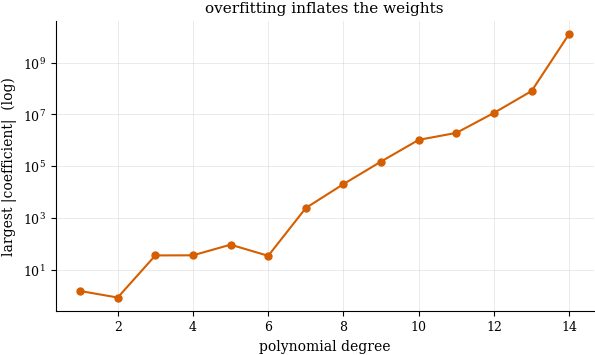

In [2]:
def poly(x, d):
    return np.vander(x, d + 1, increasing=True)     # columns [1, x, x^2, ..., x^d]

degs = range(1, 15); wmax = []
for d in degs:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")             # high-degree fit is ill-conditioned (the point)
        c = np.polyfit(xa, ya, d)
    wmax.append(np.abs(c).max())

plt.figure(figsize=(6, 3.6))
plt.semilogy(list(degs), wmax, "-o", color=ORANGE)
plt.xlabel("polynomial degree"); plt.ylabel("largest |coefficient|  (log)")
plt.title("overfitting inflates the weights"); plt.grid(alpha=0.3, which="both"); plt.show()

## 2. Ridge (ℓ₂), from scratch

Ridge minimizes $\lVert\mathbf y-\mathbf X\mathbf w\rVert^2+\lambda\lVert\mathbf w\rVert^2$. It is
smooth, so setting the gradient to zero gives a **closed form** — just add $\lambda$ to the diagonal
of $\mathbf X^\top\mathbf X$ (which also makes it invertible). We check it against scikit-learn, then
watch it smooth a wiggly degree-12 fit.

ridge matches sklearn: True


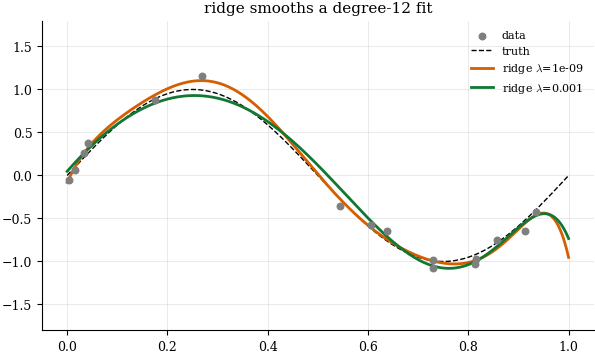

In [3]:
from sklearn.linear_model import Ridge

def fit_ridge(X, y, lam):
    d = X.shape[1]
    return np.linalg.solve(X.T @ X + lam * np.eye(d), X.T @ y)     # (X'X + lam I)^-1 X'y

w_ours = fit_ridge(Xb, yb, lam=5.0)
w_sk   = Ridge(alpha=5.0, fit_intercept=False).fit(Xb, yb).coef_
print("ridge matches sklearn:", np.allclose(w_ours, w_sk))

# ridge tames a wiggly degree-12 fit on dataset A
scale = np.abs(poly(xa, 12)).max(0)                 # column scaling (learned from training)
Phi = poly(xa, 12) / scale
xg = np.linspace(0, 1, 300); Pg = poly(xg, 12) / scale
plt.figure(figsize=(6, 3.6))
plt.scatter(xa, ya, color=GRAY, s=22, zorder=3, label="data")
plt.plot(xg, np.sin(2 * np.pi * xg), "--", color="black", lw=1, label="truth")
for lam, col in [(1e-9, ORANGE), (1e-3, GREEN)]:
    w = fit_ridge(Phi, ya, lam)
    plt.plot(xg, np.clip(Pg @ w, -2, 2), color=col, lw=2, label=fr"ridge $\lambda$={lam:g}")
plt.ylim(-1.8, 1.8); plt.legend(fontsize=8); plt.title("ridge smooths a degree-12 fit"); plt.show()

## 3. Lasso (ℓ₁), from scratch

The $\lvert\cdot\rvert$ penalty has a **kink at 0**, so there is no closed form. But the problem is
convex and *separable per coordinate*, so we cycle through the weights, updating each with a
**soft-threshold** — the 1-D lasso solution

$$S_\lambda(\rho)=\operatorname{sign}(\rho)\,\max(\lvert\rho\rvert-\lambda,\,0).$$

This is **coordinate descent**. The exact zeros — and feature selection — fall out on their own.

In [4]:
from sklearn.linear_model import Lasso

def soft_threshold(a, g):
    return np.sign(a) * np.maximum(np.abs(a) - g, 0.0)

def fit_lasso(X, y, lam, n_iter=1000, tol=1e-9):
    # coordinate descent for (1/2n)||y - Xw||^2 + lam*||w||_1  (scikit-learn's objective)
    n, d = X.shape
    w = np.zeros(d)
    z = (X ** 2).mean(0)                    # (1/n)||x_j||^2  (=1 for standardized columns)
    r = y - X @ w                           # residual
    for _ in range(n_iter):
        w_old = w.copy()
        for j in range(d):
            r += X[:, j] * w[j]             # add feature j back into the residual
            rho = (X[:, j] @ r) / n
            w[j] = soft_threshold(rho, lam) / z[j]
            r -= X[:, j] * w[j]             # subtract the updated feature j
        if np.max(np.abs(w - w_old)) < tol:
            break
    return w

w_ours = fit_lasso(Xb, yb, lam=0.5)
w_sk   = Lasso(alpha=0.5, fit_intercept=False, max_iter=100000, tol=1e-12).fit(Xb, yb).coef_
print("lasso matches sklearn:", np.allclose(w_ours, w_sk, atol=1e-3))
print("our weights :", w_ours)
print("sklearn     :", w_sk)
print("non-zero    :", int(np.sum(np.abs(w_ours) > 1e-8)), "of", Xb.shape[1], "features")

lasso matches sklearn: True
our weights : [-2.101  0.688 47.16   2.288 76.44  81.999  1.969 -0.   ]
sklearn     : [-2.101  0.688 47.16   2.288 76.44  81.999  1.969 -0.   ]
non-zero    : 7 of 8 features


## 4. The shrinkage maps behind the corners

For uncorrelated (standardized) features each weight is shrunk on its own, as a function of its
least-squares value $w_{OLS}$. **Ridge** multiplies by $1/(1+\lambda)$ — a proportional shrink that
never reaches zero. **Lasso** subtracts a fixed amount and clips at zero — a **dead zone** that snaps
small weights to exactly $0$. That flat segment *is* the diamond's corner.

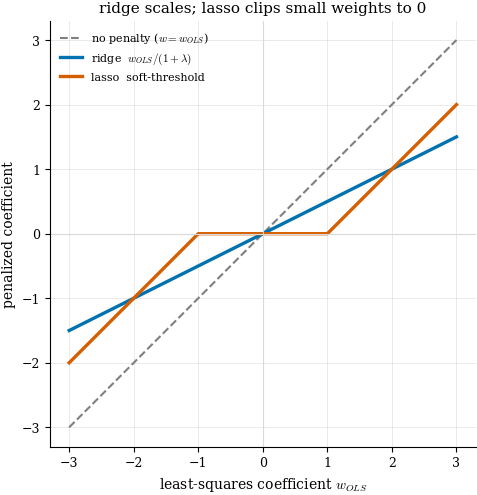

In [5]:
a = np.linspace(-3, 3, 400); lam = 1.0
plt.figure(figsize=(5.2, 5))
plt.plot(a, a, "--", color=GRAY, label=r"no penalty ($w=w_{OLS}$)")
plt.plot(a, a / (1 + lam), color=BLUE, lw=2.4, label=r"ridge  $w_{OLS}/(1+\lambda)$")
plt.plot(a, soft_threshold(a, lam), color=ORANGE, lw=2.4, label="lasso  soft-threshold")
plt.axhline(0, color="0.85", lw=0.8); plt.axvline(0, color="0.85", lw=0.8)
plt.xlabel(r"least-squares coefficient $w_{OLS}$"); plt.ylabel("penalized coefficient")
plt.title("ridge scales; lasso clips small weights to 0"); plt.legend(fontsize=8)
plt.gca().set_aspect("equal"); plt.show()

## 5. Coefficient paths as $\lambda$ grows

Sweep the penalty and plot every coefficient. **Ridge** shrinks all of them smoothly (none reaches
zero); **lasso** drives them to *exactly* zero one by one — the signature of feature selection.
(scikit-learn calls the penalty strength `alpha`; here it is our $\lambda$.)

C:\Users\JAN\AppData\Local\Temp\ipykernel_52480\3668517950.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


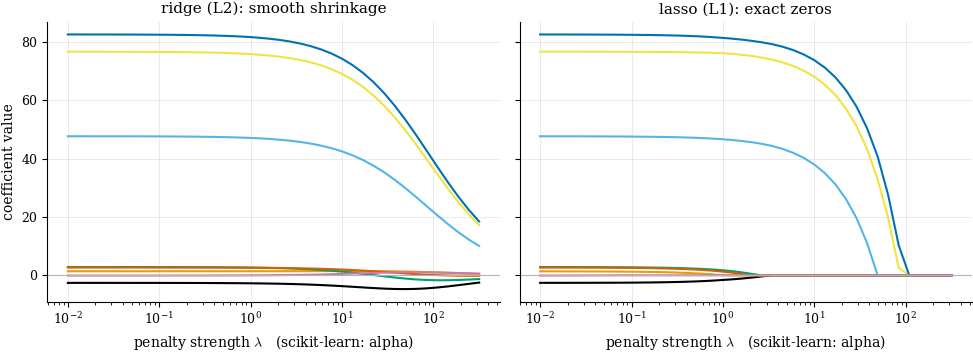

lasso non-zero at the largest lambda: 0 of 8


In [6]:
lams = np.logspace(-2, 2.5, 40)
ridge_path = np.array([fit_ridge(Xb, yb, l) for l in lams])
lasso_path = np.array([fit_lasso(Xb, yb, l) for l in lams])

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
ax[0].plot(lams, ridge_path); ax[0].set_title("ridge (L2): smooth shrinkage")
ax[1].plot(lams, lasso_path); ax[1].set_title("lasso (L1): exact zeros")
for a_ in ax:
    a_.set_xscale("log"); a_.axhline(0, color="0.7", lw=0.8)
    a_.set_xlabel(r"penalty strength $\lambda$   (scikit-learn: alpha)")
ax[0].set_ylabel("coefficient value")
plt.tight_layout(); plt.show()
print("lasso non-zero at the largest lambda:", int(np.sum(np.abs(lasso_path[-1]) > 1e-8)), "of", Xb.shape[1])

## Recap & exercises

**Recap.**
* Overfitting = **exploding weights**; regularization caps them.
* **Ridge** = a one-line closed form (add $\lambda\mathbf I$); shrinks smoothly, keeps every feature.
* **Lasso** = **coordinate descent** with **soft-thresholding**; shrinks *and* selects (exact zeros).
* Both match scikit-learn to machine precision / solver tolerance.

**Exercises.**
1. In Section 3, raise `lam`. How many lasso weights survive? Compare with the ridge path at the same
   $\lambda$.
2. Add two **correlated** copies of an informative feature to `Xb`. What does lasso do with them, and
   what does ridge do? (Ridge *shares*; lasso *picks one*.)
3. Implement **elastic net** (penalty $\lambda_1\lVert w\rVert_1+\lambda_2\lVert w\rVert_2^2$): its
   coordinate update is a soft-threshold divided by $(1+\lambda_2)$.
4. Time `fit_lasso` against `sklearn.linear_model.Lasso` as the number of features grows.

*Next:* **03c — Choosing the model (cross-validation)**, which picks $\lambda$ honestly.